# bentum2023: clock drift between EEG and audio

The EEG amplifier and the stimulus PC run on separate clocks. Over a 900 s dialogue even a few tens of ppm add up to
tens of milliseconds, which barely matters for envelope TRFs but matters a lot for high-frequency (>100 Hz) responses.

This notebook uses only the timing fields in `XML_INFO/PP*/blocks.xml` to answer four questions:

1. Which timing fields are **measured** (EEG markers) and which are **nominal** (computed from audio durations)?
2. Is the end-of-block discrepancy real **drift** (grows with duration), or a fixed **marker latency**?
3. Should drift be corrected with **one factor for the whole dataset**, or estimated **per recording**?
4. How should multi-file blocks (news `k`, some stories `o`) be corrected?

**Summary**
- Only `st_sample` and `et_sample` are measured. `fid_st`/`fid_et` are nominal: the first file starts at `st_sample`, and every later onset is computed from nominal durations plus an exact 900 ms gap.
- The discrepancy `et_sample - fid_et[-1]` grows linearly with duration, at about **31 ppm** across all blocks (about 34 ppm for single-file blocks only), It is mostly drift, plus a small constant end-marker offset of about **−1.2 samples** (95% CI −2.3 to −0.2). Modelling that offset removes most of the apparent drift difference between short and long blocks (section 2b).
- Drift is stable **within a recording** but varies a lot **between recordings**, even for the same participant (SD about 6 ppm, range about 18–44 ppm). A per-recording estimate is well determined, whereas one factor for the whole dataset leaves errors of up to about 14 ms at the end of a dialogue.
- Proposed correction: estimate drift per recording (`.vhdr`), treat each block as one timeline on the audio clock, and stretch nominal offsets by `(1 + drift)`.
- The XML cannot tell us the absolute audio output latency, i.e. the fixed lag between the marker and sound reaching the ear. That needs a physiological estimate, such as a high-frequency match-mismatch decoder or the latency of the brainstem response peak.

In [1]:
import glob
import os
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


def theilslopes(y, x):
    # scipy.stats.theilslopes sorts its inputs in place (scipy 1.15), which silently scrambles
    # pandas columns passed to it; always hand it copies
    return stats.theilslopes(np.array(y, dtype=float), np.array(x, dtype=float))

XML_ROOT = "/data_storage/gu08wuvu/datasets/bentum2023/downloaded/XML_INFO"
EEG_FS = 1000  # Hz; XML sample fields are in EEG samples

rows = []
for path in glob.glob(os.path.join(XML_ROOT, "PP*", "blocks.xml")):
    for el in ET.parse(path).getroot():
        rows.append({c.tag: (c.text or "").strip() for c in el})
blocks = pd.DataFrame(rows)

ints = lambda s: [int(v) for v in s.split(",") if v and v != "NA"]
for col in ["pp_id", "block_number", "st_sample", "et_sample", "duration_sample", "sample_inacc"]:
    blocks[col] = pd.to_numeric(blocks[col])
for col in ["fid_st", "fid_et"]:
    blocks[col] = blocks[col].apply(ints)
blocks["n_files"] = blocks["fid_st"].str.len()
blocks["recording"] = blocks["vhdr_fn"]  # one BrainVision recording = one clock run

print(f"{len(blocks)} blocks, {blocks.pp_id.nunique()} participants, {blocks.recording.nunique()} recordings")
blocks.groupby(["exp_type", blocks.n_files > 1]).size().rename("blocks").to_frame()

1620 blocks, 48 participants, 150 recordings


blocks
exp_type n_files        
ifadv    False       284
k        True       1001
o        False       144
         True        191

## 1. Measured vs nominal fields

If `fid_*` were measured markers, the gaps between consecutive files would jitter and IFADV file durations would vary.
Neither happens: the first file always starts exactly at the block's `st_sample`, IFADV files last exactly 900,000
samples, and every gap between files is exactly 0 (concatenated stories) or 900 samples (news).

In [2]:
first_st = blocks.fid_st.str[0]
last_et = blocks.fid_et.str[-1]
print("first fid_st == st_sample:         ", (first_st == blocks.st_sample).mean())

ifadv = blocks[blocks.exp_type == "ifadv"]
print("IFADV fid_et - fid_st values:      ", (ifadv.fid_et.str[0] - ifadv.fid_st.str[0]).value_counts().to_dict())

gaps = pd.Series([b - a for st, et in zip(blocks.fid_st, blocks.fid_et) for a, b in zip(et[:-1], st[1:])])
print("gaps between consecutive files:    ", gaps.value_counts().to_dict())

first fid_st == st_sample:          1.0
IFADV fid_et - fid_st values:       {900000: 284}
gaps between consecutive files:     {900: 12249, 0: 191}


So each block has two measured anchors, `st_sample` (the onset marker) and `et_sample` (the offset marker). Everything
in between is on the **stimulus clock**. The end-of-block discrepancy, in EEG samples, is

$$\text{inacc} = \text{et\_sample} - \text{fid\_et}_{\text{last}}$$

This is what the authors store as `sample_inacc`, but only approximately: in about 40% of multi-file blocks the stored
value is off by ±1 sample, probably from rounding in their pipeline. Below we compute it from the raw fields.

In [3]:
blocks["dur"] = last_et - first_st                  # nominal block duration (samples at 1 kHz)
blocks["inacc"] = blocks.et_sample - last_et        # measured minus nominal end
blocks["ppm"] = blocks.inacc / blocks.dur * 1e6

print("inacc == sample_inacc:", (blocks.inacc == blocks.sample_inacc).groupby(blocks.n_files > 1).mean().rename({False: "single-file", True: "multi-file"}).to_dict())

outlier = blocks.inacc.abs() > 1000
print(f"blocks with |inacc| > 1000 samples (marker problems): {outlier.sum()}")
ok = blocks[~outlier].copy()

inacc == sample_inacc: {'single-file': 0.9953271028037384, 'multi-file': 0.4412751677852349}
blocks with |inacc| > 1000 samples (marker problems): 0


## 2. Drift or latency?

A fixed marker latency adds the same number of samples to every block. Drift adds samples in proportion to duration.
IFADV blocks (900 s), stories (about 690 s) and news blocks (about 250 s) differ in duration, so the two can be
separated by fitting

$$\text{inacc} = \text{offset} + \text{drift} \times \text{duration}$$

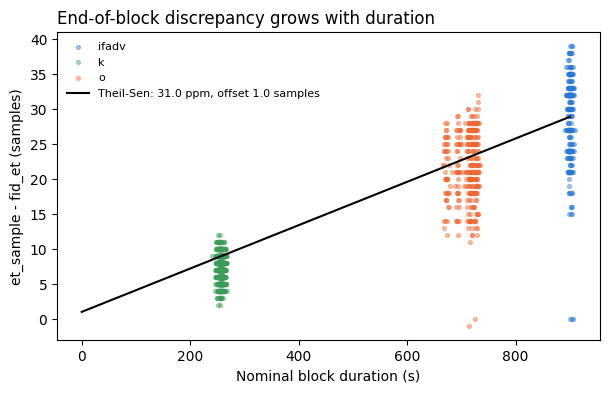

all blocks:         drift 30.97 ppm (95% CI 29.68 to 32.09), offset 0.98 samples
single-file blocks: drift 33.94 ppm (95% CI 29.26 to 39.53), offset -4.05 samples


In [4]:
colors = {"ifadv": "#2a78d6", "o": "#eb6834", "k": "#3b9c5a"}
fig, ax = plt.subplots(figsize=(7, 4))
for exp, g in ok.groupby("exp_type"):
    jitter = np.random.default_rng(0).normal(0, 3, len(g))
    ax.scatter(g.dur / EEG_FS + jitter, g.inacc, s=8, alpha=0.4, color=colors[exp], label=exp)

slope, intercept, lo, hi = theilslopes(ok.inacc, ok.dur)
x = np.array([0, ok.dur.max()])
ax.plot(x / EEG_FS, intercept + slope * x, color="k", lw=1.5,
        label=f"Theil-Sen: {slope*1e6:.1f} ppm, offset {intercept:.1f} samples")
ax.set_xlabel("Nominal block duration (s)")
ax.set_ylabel("et_sample - fid_et (samples)")
ax.legend(frameon=False, fontsize=8)
ax.set_title("End-of-block discrepancy grows with duration", loc="left")
plt.show()

print(f"all blocks:         drift {slope*1e6:.2f} ppm (95% CI {lo*1e6:.2f} to {hi*1e6:.2f}), offset {intercept:.2f} samples")
single = ok[ok.n_files == 1]
s1, i1, lo1, hi1 = theilslopes(single.inacc, single.dur)
print(f"single-file blocks: drift {s1*1e6:.2f} ppm (95% CI {lo1*1e6:.2f} to {hi1*1e6:.2f}), offset {i1:.2f} samples")

The discrepancy grows with duration, so most of it is clock drift: the EEG clock runs about 30–35 ppm slow relative
to the audio. Restricted to single-file blocks, the fit gives about 34 ppm, whose confidence interval includes the
35.55 ppm previously estimated from them.

The fitted line does not pass through the middle of every cluster, though, and the intercept printed above should not
be read as the marker offset. Section 2b explains why and estimates the offset properly.

## 2b. A constant end-marker offset

Shifting the points up by about 2 samples makes the plot above look better. That happens for two reasons:

- **scipy's Theil-Sen intercept is `median(y) - slope × median(x)`,** not the median residual. With durations
  bunched into three clusters, that value is not the centre of the data.
- **The pooled slope is a compromise.** Each experiment type shows a different apparent drift, so a single line
  cannot pass through all three clusters.

In [5]:
resid = ok.inacc - (intercept + slope * ok.dur)
resid.groupby(ok.exp_type).median().round(2).rename("median residual from pooled fit (samples)").to_frame()

,median residual from pooled fit (samples)
exp_type,
ifadv,1.15
k,-1.85
o,-1.46


The apparent differences in drift between experiment types can be explained by a constant offset $c$ in the end
discrepancy:

$$\text{inacc} = c + \text{drift}_\text{rec} \times \text{duration}
\quad\Rightarrow\quad
\frac{\text{inacc}}{\text{duration}} = \text{drift}_\text{rec} + \frac{c}{\text{duration}}$$

A per-recording estimate that ignores $c$ is biased by $c / \text{duration}$. That is about 3.9 ppm per sample for
256 s news blocks, but only 1.1 ppm per sample for 900 s dialogues. $c$ cannot be separated from drift within one
recording, because all its blocks last about the same. Across recordings, block duration varies from about 250 s
to 900 s, and drift differs randomly from one recording to the next. Regressing each recording's raw ppm on
$10^6/\text{duration}$ therefore estimates $c$ as the slope, and the mean drift as the intercept.

end-marker offset c = -1.18 samples (95% CI -2.25 to -0.17); mean drift 32.58 ppm


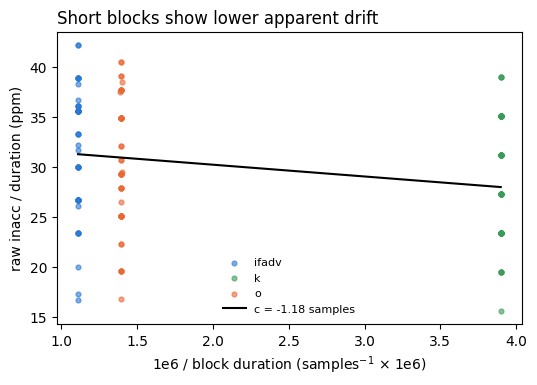

,c = 0,c = -1.18
median per-recording drift (ppm),,
ifadv,33.3,34.6
k,27.3,31.9
o,29.4,31.0


In [6]:
raw_rec = ok.groupby(["recording", "pp_id", "exp_type"]).agg(
    inacc=("inacc", "median"), dur=("dur", "median")).reset_index()
raw_rec["ppm_raw"] = raw_rec.inacc / raw_rec.dur * 1e6
inv_dur = 1e6 / raw_rec.dur

OFFSET, mean_drift, c_lo, c_hi = theilslopes(raw_rec.ppm_raw, inv_dur)
print(f"end-marker offset c = {OFFSET:.2f} samples (95% CI {c_lo:.2f} to {c_hi:.2f}); mean drift {mean_drift:.2f} ppm")

fig, ax = plt.subplots(figsize=(6, 3.8))
for exp, g in raw_rec.groupby("exp_type"):
    ax.scatter(1e6 / g.dur, g.ppm_raw, s=12, alpha=0.6, color=colors[exp], label=exp)
x = np.linspace(inv_dur.min(), inv_dur.max(), 2)
ax.plot(x, mean_drift + OFFSET * x, color="k", lw=1.5, label=f"c = {OFFSET:.2f} samples")
ax.set_xlabel("1e6 / block duration (samples$^{-1}$ × 1e6)")
ax.set_ylabel("raw inacc / duration (ppm)")
ax.set_title("Short blocks show lower apparent drift", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.show()

pd.DataFrame({
    "c = 0": raw_rec.groupby("exp_type").ppm_raw.median(),
    f"c = {OFFSET:.2f}": ((raw_rec.inacc - OFFSET) / raw_rec.dur * 1e6).groupby(raw_rec.exp_type).median(),
}).round(1).rename_axis("median per-recording drift (ppm)")

With the offset included, the gap between experiment types shrinks from about 6 ppm to about 3.5 ppm. The news
recordings move the most (+4.6 ppm), because their blocks are the shortest. The news recordings remain a few ppm
below the dialogues. Offsets towards the lower end of the confidence interval (about −2 samples) would close most of
that gap, and would also bring IFADV and news close to the 35.55 ppm estimated earlier. The data cannot pin $c$ down
more precisely than that, but it is clearly negative: the end marker arrives about 1–2 samples *before* the nominal
end of the audio.

**Can index conventions explain it?** Only partly.
- **Start conventions cancel.** `fid_st[0] == st_sample` exactly, so both come from the same marker.
- **Per-file conventions are ruled out.** Losing one sample per file would put news blocks (13+ files) about 13
  samples off. Single-file and two-file story blocks also show the same drift.
- **The end convention can account for one sample.** For example, `fid_et = fid_st + N` points one past the last
  audio sample, whereas the offset marker may be written on the last sample.
- **The rest is probably not indexing.** A plausible source is the end marker being sent when the last audio buffer
  is queued rather than when it finishes playing, which would be about 1 ms of output buffering.

Once the CGN audio is available, comparing each file's `fid_et - fid_st` with its exact wav length will show the
authors' duration convention and separate these explanations.

From here on, drift is estimated as `(inacc - c) / duration`.

In [7]:
ok["ppm"] = (ok.inacc - OFFSET) / ok.dur * 1e6

## 3. One factor for the dataset, or one per recording?

If drift were a fixed property of the hardware, every recording would show the same ppm. Instead:

In [8]:
per_rec = ok.groupby(["recording", "pp_id", "exp_type"]).agg(
    ppm=("ppm", "median"), sd_within=("ppm", "std"), n_blocks=("ppm", "size"), dur_s=("dur", lambda d: d.median() / EEG_FS),
).reset_index()

summary = per_rec.groupby("exp_type").agg(
    recordings=("ppm", "size"),
    median_block_s=("dur_s", "median"),
    between_rec_sd=("ppm", "std"),
    between_rec_min=("ppm", "min"),
    between_rec_max=("ppm", "max"),
    within_rec_sd=("sd_within", "median"),
).round(2)
summary

,recordings,median_block_s,between_rec_sd,between_rec_min,between_rec_max,within_rec_sd
exp_type,,,,,,
ifadv,51,900.00,6.20,17.98,43.53,0.57
k,49,256.64,5.88,20.14,43.60,4.16
o,50,716.76,6.41,18.39,43.40,1.01


Part of the within-recording spread is rounding. Each `fid_et` is a whole number of samples, and a multi-file block
accumulates one rounding per file, so the rounding error is about $\sqrt{n_\text{files}/12}$ samples. The table below
compares that floor with the observed spread. Where the observed spread is at or below the floor, the spread within a
recording is almost entirely rounding.

In [9]:
ok["expected_sd_ppm"] = np.sqrt(ok.n_files / 12) / ok.dur * 1e6 * np.sqrt(2)  # sqrt(2): end marker rounds too
pd.DataFrame({
    "observed within-recording SD (ppm)": per_rec.groupby("exp_type").sd_within.median(),
    "expected from rounding (ppm)": ok.groupby("exp_type").expected_sd_ppm.median(),
}).round(2)

,observed within-recording SD (ppm),expected from rounding (ppm)
exp_type,,
ifadv,0.57,0.45
k,4.16,5.85
o,1.01,0.80


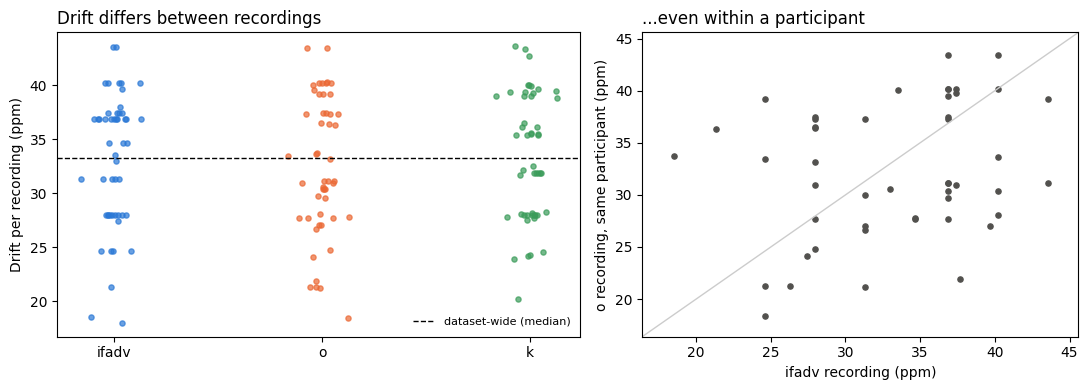

Correlation of per-recording drift across a participant's sessions:


exp_type,ifadv,k,o
exp_type,,,
ifadv,1.00,0.13,0.25
k,0.13,1.00,-0.23
o,0.25,-0.23,1.00


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.2, 1]})

ax = axes[0]
order = ["ifadv", "o", "k"]
for i, exp in enumerate(order):
    g = per_rec[per_rec.exp_type == exp]
    ax.scatter(np.full(len(g), i) + np.random.default_rng(1).normal(0, 0.06, len(g)), g.ppm,
               s=14, color=colors[exp], alpha=0.7)
ax.axhline(per_rec.ppm.median(), color="k", lw=1, ls="--", label="dataset-wide (median)")
ax.set_xticks(range(3), order)
ax.set_ylabel("Drift per recording (ppm)")
ax.set_title("Drift differs between recordings", loc="left")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
wide = per_rec.pivot_table(index="pp_id", columns="exp_type", values="ppm")
ax.scatter(wide["ifadv"], wide["o"], s=14, color="#52514e")
lim = [wide.min().min() - 2, wide.max().max() + 2]
ax.plot(lim, lim, color="#cccccc", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("ifadv recording (ppm)")
ax.set_ylabel("o recording, same participant (ppm)")
ax.set_title("...even within a participant", loc="left")
plt.tight_layout()
plt.show()

print("Correlation of per-recording drift across a participant's sessions:")
wide.corr().round(2)

Drift is about as consistent within a recording as rounding allows, yet spreads by about ±6 ppm between recordings,
and a participant's three sessions are nearly uncorrelated. Drift is therefore a property of the **recording**
(warm-up, temperature, and which run of the equipment), not of the participant or the dataset.

Note that recording is the right unit, rather than session or participant. PP8's stories, for example, were
recorded in two files (`pp008_o.vhdr`, `pp008_o_b.vhdr`), and each file is a separate clock run.

### How large is the error in time?

In [11]:
global_ppm = per_rec.ppm.median()
err = per_rec.assign(
    err_none_ms=lambda d: d.ppm * 900 / 1e3,                                  # no correction, end of a 900 s dialogue
    err_global_ms=lambda d: (d.ppm - global_ppm) * 900 / 1e3,                 # dataset-wide factor
)
err[err.exp_type == "ifadv"][["err_none_ms", "err_global_ms"]].abs().describe().round(1).loc[["mean", "50%", "max"]]

,err_none_ms,err_global_ms
mean,29.7,4.7
50%,31.2,4.2
max,39.2,13.8


At the end of a 900 s dialogue, no correction is off by about 30 ms. A dataset-wide factor reduces the typical
error to about 4–5 ms, but some recordings are still off by about 14 ms. A 100 Hz response has a 10 ms period, so
those recordings would be completely out of phase by the end of the block. A per-recording estimate has an
uncertainty of about 0.5 ppm (under 1 ms at 900 s), which is the level needed for high-frequency analyses.

## 4. Correcting multi-file blocks

The intermediate onsets of a news block are nominal: they are based on nominal file durations and the 900 ms
gaps, all measured on the stimulus clock. The consistent treatment is to map the **whole block** from the stimulus clock
to the EEG clock with one stretch, anchored at the measured `st_sample`:

$$\text{eeg\_sample}(t) = \text{st\_sample} + (t - \text{st\_sample}) \times (1 + \text{drift})$$

Here $t$ is any nominal sample (`fid_st`, `fid_et`, word onsets). For a single-file block this reduces to
stretching the file. For a news block it moves each later fragment progressively further.

The gaps may have been timed by the stimulus software on the PC clock rather than the audio clock. That would
introduce a second, much smaller error, but only over the 900 ms gaps, so it is negligible.

In [12]:
drift_by_recording = per_rec.set_index("recording").ppm / 1e6

def corrected_windows(block):
    # (fid, start, stop) in EEG samples for each file in a block, drift-corrected
    d = drift_by_recording.get(block.recording, global_ppm / 1e6)  # fall back to the dataset-wide value
    anchor = block.st_sample
    to_eeg = lambda t: anchor + round((t - anchor) * (1 + d))
    return [(fid, to_eeg(st), to_eeg(et)) for fid, st, et in zip(block.fids.split(","), block.fid_st, block.fid_et)]

example = ok[(ok.exp_type == "k") & (ok.pp_id == 1)].iloc[0]
win = pd.DataFrame(corrected_windows(example), columns=["fid", "start_corr", "stop_corr"])
win["start_nominal"] = example.fid_st
win["shift_samples"] = win.start_corr - win.start_nominal
print(f"{example['name']}: drift {drift_by_recording[example.recording]*1e6:.1f} ppm, "
      f"measured end {example.et_sample} (expected {example.et_sample - OFFSET:.1f} after the offset), "
      f"corrected end of last file {win.stop_corr.iloc[-1]}")
win[["fid", "start_nominal", "start_corr", "shift_samples", "stop_corr"]]

pp1_exp-k_bid-1: drift 31.8 ppm, measured end 273011 (expected 273012.2 after the offset), corrected end of last file 273010


,fid,start_nominal,start_corr,shift_samples,stop_corr
0,fn001647,21044,21044,0,42436
1,fn001885,43335,43336,1,60837
2,fn003541,61736,61737,1,80359
3,fn006142,81257,81259,2,101539
4,fn002711,102436,102439,3,121544
5,fn004757,122441,122444,3,141925
6,fn002867,142821,142825,4,160138
7,fn002062,161034,161038,4,180371
8,fn002318,181266,181271,5,201083
9,fn002712,201977,201983,6,222157


The corrected end of the last file lands close to `et_sample - c`, which is where the model in section 2b says it
should be. That is not automatic: this block's drift comes from the median of all blocks in its recording, not from
the block itself.

## 5. What the XML cannot tell us

- **Absolute latency.** Both anchors are markers. If the sound left the speakers a fixed *L* ms after the marker, every
  onset is late by *L* and nothing in the XML reveals it. The offset $c$ in section 2b only shows that the end marker
  runs 1–2 samples ahead of the start marker. It says nothing about the latency the two share.
- **Nonlinear drift within a recording.** A linear stretch assumes constant ppm across a block. The tight
  within-recording spread suggests this holds, but it is only tested at the block level.

Both are best checked physiologically. A match-mismatch decoder trained on high-frequency EEG (>100 Hz) from a
well-aligned dataset, or the latency of the brainstem response peak, could:
1. estimate one global latency *L* by scanning offsets, and
2. validate the correction by comparing held-out accuracy for **no correction / dataset-wide / per-recording**.

Short news fragments (about 20 s) will give noisy decoder estimates on their own, but they are corrected with drift
estimated from their whole recording, so they do not need their own estimates.

## Recommendation for the adaptor

Add `drift_correction={"recording" (default), "global", None}`:
- Estimate drift per `.vhdr` recording as the median over its blocks of `(et_sample - fid_et[-1] - c) / duration`,
  with the end-marker offset $c$ (about −1.2 samples) fixed across the dataset, as in section 2b. Skip blocks with
  |inacc| > 1000.
- Map each file's EEG window, and the word and phone times, through `st_sample + (t - st_sample) × (1 + drift)`.
- To express the cropped EEG in audio time, either set `sfreq = 1000 × (1 + drift)` (exact, no interpolation, but
  the sample rate becomes non-integer) or resample the EEG back to 1000 Hz.